# Projeto de Machine Learning - Titanic

## Objetivo

O objetivo deste projeto é construir modelos de Machine Learning capazes de
prever se um passageiro do Titanic sobreviveu ou não.

A variável alvo é `Survived`:

- `0` → Não sobreviveu
- `1` → Sobreviveu

Ao longo do projeto serão realizadas etapas de exploração dos dados,
tratamento de valores ausentes, feature engineering, encoding, padronização,
treinamento de diferentes modelos, validação cruzada e otimização de
hiperparâmetros.

## 1. Carregamento da base de dados

A base utilizada é o `train.csv` disponibilizado na competição Titanic
do Kaggle.

Essa base contém as características dos passageiros e a variável
`Survived`, que será utilizada como variável alvo.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


## 2. Análise inicial dos dados

Antes de construir qualquer modelo, é necessário compreender a estrutura
da base de dados.

Nesta etapa são analisados:

- dimensão da base;
- tipos das variáveis;
- valores ausentes;
- valores duplicados;
- estatísticas descritivas;
- distribuição da variável alvo.

| Coluna        | Significado                                                                            |
| ------------- | -------------------------------------------------------------------------------------- |
| `PassengerId` | Identificador único de cada passageiro                                                 |
| `Survived`    | Variável-alvo: indica se o passageiro sobreviveu (`0 = Não`, `1 = Sim`)                |
| `Pclass`      | Classe da passagem: `1 = 1ª classe`, `2 = 2ª classe`, `3 = 3ª classe`                  |
| `Name`        | Nome do passageiro                                                                     |
| `Sex`         | Sexo do passageiro                                                                     |
| `Age`         | Idade do passageiro em anos                                                            |
| `SibSp`       | Quantidade de irmãos, irmãs, marido ou esposa a bordo                                  |
| `Parch`       | Quantidade de pais e filhos a bordo                                                    |
| `Ticket`      | Número ou código do bilhete                                                            |
| `Fare`        | Valor pago pela passagem                                                               |
| `Cabin`       | Número da cabine                                                                       |
| `Embarked`    | Porto onde o passageiro embarcou: `C = Cherbourg`, `Q = Queenstown`, `S = Southampton` |


In [2]:
import pandas as pd

df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. Análise Exploratória dos Dados (EDA)

Antes da construção dos modelos, é realizada uma análise exploratória para
identificar padrões, relações entre as variáveis e possíveis características
relevantes para a sobrevivência dos passageiros.

O objetivo desta etapa é compreender melhor a estrutura dos dados, verificar
possíveis relações com a variável alvo e apoiar as decisões tomadas durante
o pré-processamento e a modelagem.

In [65]:
# Criando uma cópia da base apenas para a análise exploratória.
# Dessa forma, qualquer operação realizada durante a EDA
# não altera o DataFrame original utilizado posteriormente.

df_eda = df.copy()

### 3.1 Distribuição da variável alvo

Primeiramente, é analisada a distribuição da variável `Survived`.

Essa análise permite verificar a proporção entre passageiros que sobreviveram
e passageiros que não sobreviveram, além de identificar um possível
desbalanceamento entre as classes.

In [66]:
# Quantidade absoluta de passageiros em cada classe
contagem_survived = df_eda["Survived"].value_counts()

# Proporção em porcentagem
proporcao_survived = (
    df_eda["Survived"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Quantidade:")
print(contagem_survived)

print("\nPorcentagem:")
print(proporcao_survived)

Quantidade:
Survived
0    549
1    342
Name: count, dtype: int64

Porcentagem:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


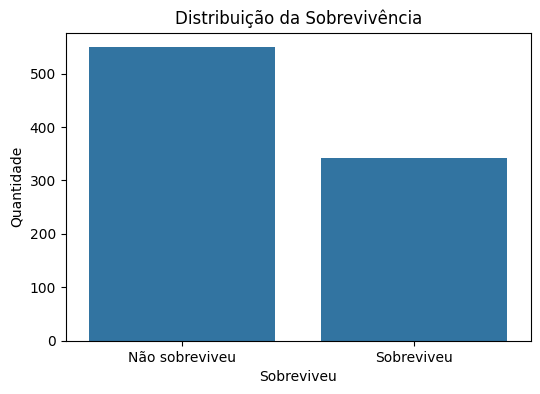

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_eda,
    x="Survived"
)

plt.title("Distribuição da Sobrevivência")
plt.xlabel("Sobreviveu")
plt.ylabel("Quantidade")

plt.xticks(
    [0, 1],
    ["Não sobreviveu", "Sobreviveu"]
)

plt.show()

### 3.2 Taxa de sobrevivência por sexo

Nesta etapa é analisada a relação entre o sexo do passageiro e sua taxa de
sobrevivência.

Como `Survived` possui valores 0 e 1, calcular sua média dentro de cada grupo
representa diretamente a proporção de sobreviventes.

In [68]:
# Calculando a média de Survived para cada sexo.
# Como Survived é 0 ou 1, a média representa a taxa de sobrevivência.

sobrevivencia_sexo = (
    df_eda
    .groupby("Sex")["Survived"]
    .mean()
)

print(sobrevivencia_sexo)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [69]:
sobrevivencia_sexo_pct = sobrevivencia_sexo * 100

print(sobrevivencia_sexo_pct.round(2))

Sex
female    74.20
male      18.89
Name: Survived, dtype: float64


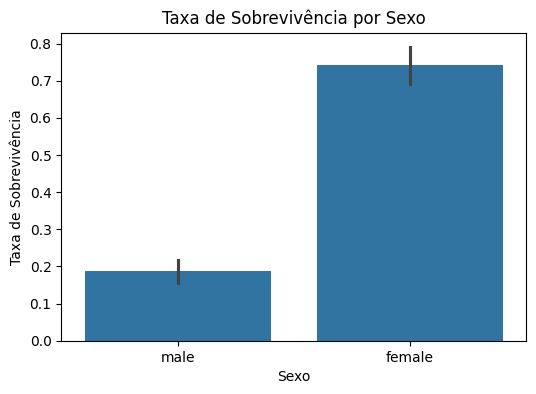

In [70]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=df_eda,
    x="Sex",
    y="Survived"
)

plt.title("Taxa de Sobrevivência por Sexo")
plt.xlabel("Sexo")
plt.ylabel("Taxa de Sobrevivência")

plt.show()

### 3.3 Taxa de sobrevivência por classe

A variável `Pclass` representa a classe da passagem do passageiro.

Nesta análise, será verificado se passageiros de diferentes classes
apresentaram taxas de sobrevivência distintas.

In [71]:
# Calculando a taxa média de sobrevivência em cada classe

sobrevivencia_classe = (
    df_eda
    .groupby("Pclass")["Survived"]
    .mean()
)

print((sobrevivencia_classe * 100).round(2))

Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64


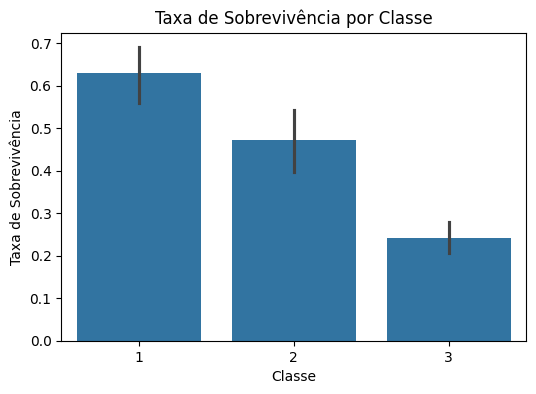

In [72]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=df_eda,
    x="Pclass",
    y="Survived"
)

plt.title("Taxa de Sobrevivência por Classe")
plt.xlabel("Classe")
plt.ylabel("Taxa de Sobrevivência")

plt.show()

### 3.4 Sobrevivência por sexo e classe

Analisar uma variável isoladamente pode esconder relações importantes.

Por isso, nesta etapa será analisada simultaneamente a influência de `Sex`
e `Pclass` sobre a taxa de sobrevivência.

Uma tabela dinâmica será utilizada para comparar a taxa média de sobrevivência
para cada combinação de sexo e classe.

In [73]:
# Pivot Table:
# Linhas   -> Pclass
# Colunas  -> Sex
# Valores  -> média de Survived

pivot_survival = df_eda.pivot_table(
    values="Survived",
    index="Pclass",
    columns="Sex",
    aggfunc="mean"
)

# Transformando em porcentagem para facilitar a interpretação
pivot_survival_pct = pivot_survival * 100

pivot_survival_pct.round(2)

Sex,female,male
Pclass,,
1,96.81,36.89
2,92.11,15.74
3,50.00,13.54


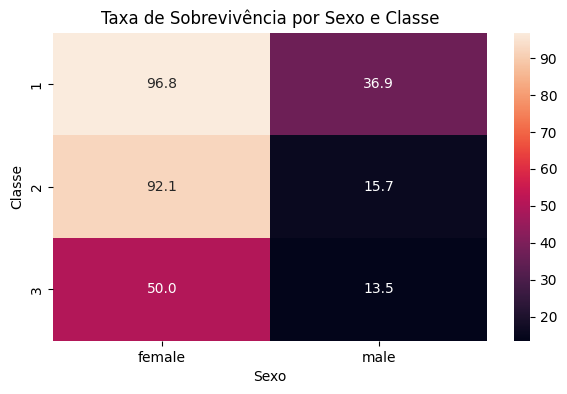

In [74]:
plt.figure(figsize=(7, 4))

sns.heatmap(
    pivot_survival_pct,
    annot=True,
    fmt=".1f"
)

plt.title("Taxa de Sobrevivência por Sexo e Classe")
plt.xlabel("Sexo")
plt.ylabel("Classe")

plt.show()

### 3.5 Distribuição da variável Age

Nesta etapa é analisada a distribuição das idades dos passageiros.

Essa análise permite observar a concentração das idades, possíveis valores
extremos e o formato da distribuição.

Também será calculada a assimetria (skewness), que ajuda a verificar se a
distribuição é aproximadamente simétrica ou apresenta uma cauda mais longa
para algum dos lados.

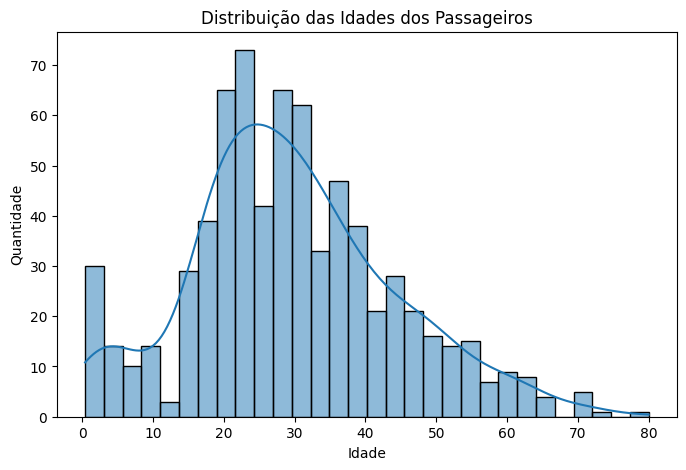

In [75]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_eda["Age"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribuição das Idades dos Passageiros")
plt.xlabel("Idade")
plt.ylabel("Quantidade")

plt.show()

In [76]:
# Skewness da variável Age
# Valores próximos de 0 indicam distribuição mais simétrica.
# Valores positivos indicam maior cauda à direita.
# Valores negativos indicam maior cauda à esquerda.

skew_age = df_eda["Age"].skew()

print("Skewness de Age:", round(skew_age, 4))

Skewness de Age: 0.3891


### 3.6 Distribuição da tarifa por classe

A variável `Fare` representa o valor pago pela passagem.

Como é esperado que a tarifa tenha relação com a classe da passagem,
será utilizado um boxplot para comparar sua distribuição entre as diferentes
classes e identificar possíveis valores extremos.

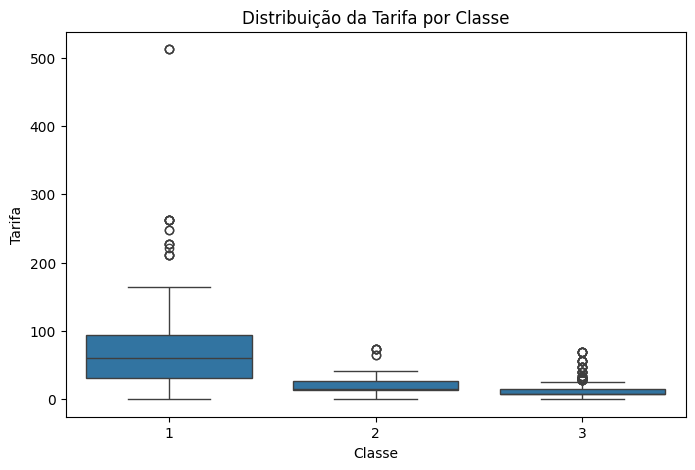

In [77]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_eda,
    x="Pclass",
    y="Fare"
)

plt.title("Distribuição da Tarifa por Classe")
plt.xlabel("Classe")
plt.ylabel("Tarifa")

plt.show()

### 3.7 Correlação entre variáveis numéricas

A matriz de correlação permite analisar relações lineares entre as variáveis
numéricas da base.

Nesta etapa, será observada especialmente a correlação das variáveis com
`Survived`.

É importante lembrar que correlação não implica causalidade e que variáveis
categóricas não são adequadamente representadas nessa análise caso ainda
estejam armazenadas como texto.

In [78]:
# Selecionando apenas variáveis numéricas

df_numerico = df_eda.select_dtypes(
    include=["int64", "float64"]
)

# Calculando a matriz de correlação
matriz_correlacao = df_numerico.corr()

matriz_correlacao

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


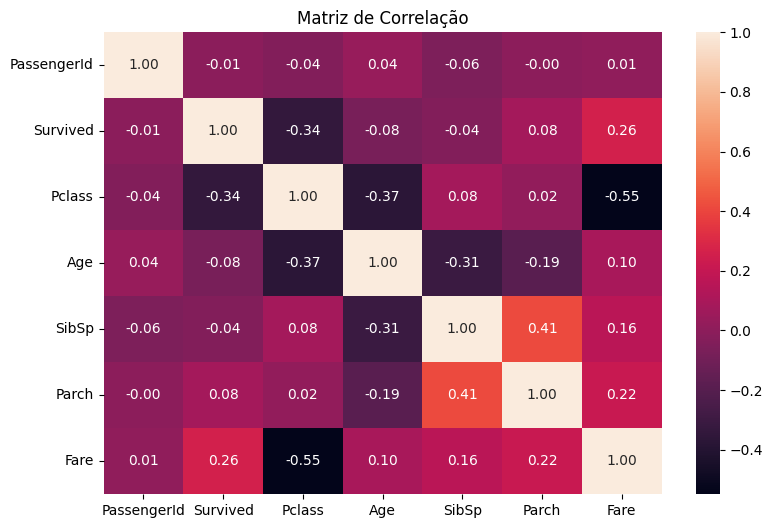

In [79]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt=".2f"
)

plt.title("Matriz de Correlação")
plt.show()

In [80]:
correlacao_survived = (
    matriz_correlacao["Survived"]
    .sort_values(ascending=False)
)

print(correlacao_survived)

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64


### 3.8 Conclusões da análise exploratória

A análise exploratória permitiu identificar alguns padrões relevantes na base
do Titanic.

Observou-se uma diferença significativa na taxa de sobrevivência entre homens
e mulheres, indicando que `Sex` pode possuir forte poder preditivo.

Também foi observada uma relação entre `Pclass` e sobrevivência, com
passageiros de classes superiores apresentando maiores taxas de sobrevivência.

A análise conjunta de sexo e classe mostrou que essas características podem
interagir na definição da probabilidade de sobrevivência.

A distribuição de `Age` apresentou leve assimetria e valores ausentes,
reforçando a necessidade de um tratamento adequado antes da modelagem.

A variável `Fare` apresentou grande variação entre as classes e alguns valores
extremos, especialmente entre passageiros da primeira classe.

A matriz de correlação mostrou que, entre as variáveis numéricas, `Pclass`
apresentou uma das relações mais fortes com `Survived`, com correlação
aproximadamente igual a **-0,34**. O sinal negativo indica que, à medida que
o valor de `Pclass` aumenta de 1 para 3, a sobrevivência tende a diminuir.

A variável `Fare` apresentou correlação positiva de aproximadamente **0,26**
com `Survived`, sugerindo que passageiros que pagaram tarifas maiores
apresentaram maior tendência de sobrevivência.

Também foi observada uma correlação negativa relativamente forte entre
`Pclass` e `Fare` (**-0,55**), o que é coerente com o fato de passageiros
da primeira classe normalmente pagarem tarifas mais elevadas.

Além disso, `SibSp` e `Parch` apresentaram correlação positiva de
aproximadamente **0,41**, indicando que passageiros que viajavam com irmãos
ou cônjuges também tendiam, em certa medida, a viajar com pais ou filhos.

É importante destacar que a matriz de correlação considera apenas relações
lineares entre variáveis numéricas. Variáveis categóricas importantes, como
`Sex` e `Embarked`, não aparecem diretamente nessa análise enquanto estão
representadas como texto. Portanto, uma correlação baixa não significa
necessariamente que uma variável seja pouco relevante para o modelo.

De forma geral, a EDA revelou relações importantes entre características
socioeconômicas, demográficas e a sobrevivência dos passageiros, fornecendo
contexto para as etapas posteriores de pré-processamento e modelagem.

## 4. Verificação dos títulos presentes nos nomes e sua relação com a idade

A variável `Name` contém, além do nome do passageiro, títulos como `Mr`, `Mrs`, `Miss`, `Master`, `Dr`, entre outros.

Esses títulos podem estar relacionados à idade do passageiro. Por exemplo, `Master` tende a representar meninos mais jovens, enquanto títulos como `Mr` e `Mrs` geralmente estão associados a adultos.

Por esse motivo, antes de remover a variável `Name`, será extraído o título de cada passageiro para verificar se essa informação pode auxiliar no tratamento dos valores ausentes da variável `Age`.

O objetivo desta etapa não é utilizar o nome completo diretamente no modelo, mas aproveitar uma informação relevante contida nele para realizar uma imputação de idade mais coerente.

In [8]:
df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.")

In [9]:
df["Title"]

,Title
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr
...,...
886,Rev
887,Miss
888,Miss
889,Mr


In [10]:
df['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


## 5. Separação entre variáveis independentes e variável alvo

A variável `Survived` será utilizada como alvo (`y`).

As demais variáveis selecionadas serão utilizadas como características
preditoras (`X`).

Algumas colunas foram removidas por não serem adequadas para o primeiro
modelo:

- `PassengerId`: identificador do passageiro;
- `Name`: nome completo;
- `Ticket`: código do bilhete;
- `Cabin`: grande quantidade de valores ausentes.

In [11]:
y = df["Survived"]

X = df.drop(columns=[
    "Survived",
    "Cabin",
    "PassengerId",
    "Name",
    "Ticket"
])

## 6. Separação entre treino e teste

Os dados são divididos em conjunto de treino e conjunto de teste.

O conjunto de treino será utilizado para que os modelos aprendam os
padrões existentes nos dados.

O conjunto de teste ficará separado para avaliar posteriormente a
capacidade de generalização do modelo.

Foi utilizado `stratify=y` para preservar aproximadamente a mesma
proporção de sobreviventes e não sobreviventes nos dois conjuntos.

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 6.1 Conferência da distribuição da variável alvo

Após a divisão dos dados, verifica-se se treino e teste mantiveram
proporções semelhantes das classes.

Isso é esperado devido ao uso de `stratify=y`.

In [13]:
comparacao = pd.DataFrame({
    "Completo": y.value_counts(normalize=True) * 100,
    "Treino": y_train.value_counts(normalize=True) * 100,
    "Teste": y_test.value_counts(normalize=True) * 100
})

display(comparacao.round(2))

,Completo,Treino,Teste
Survived,,,
0,61.62,61.66,61.45
1,38.38,38.34,38.55


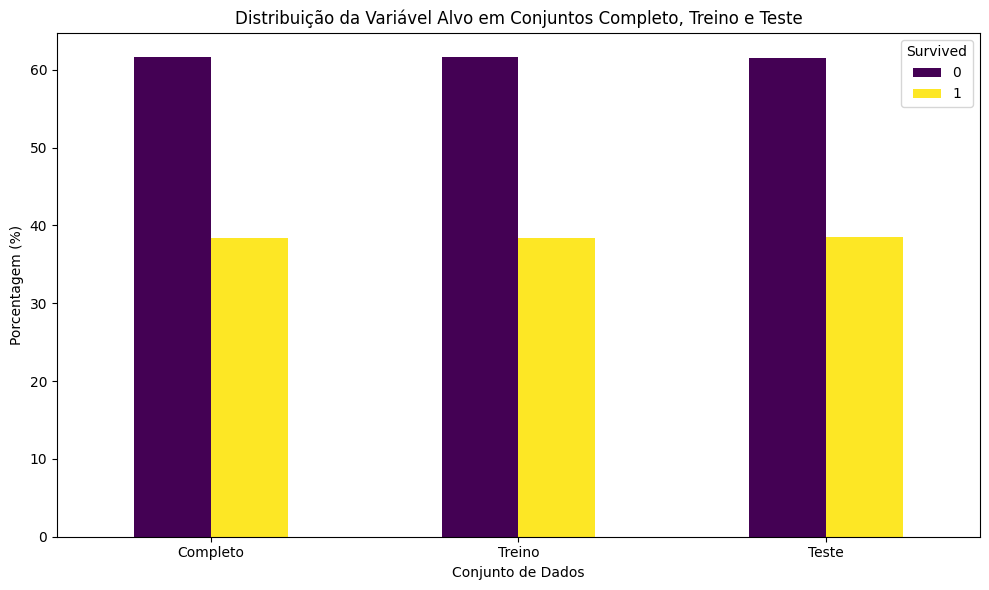

In [14]:
import matplotlib.pyplot as plt

comparacao_plot = comparacao.T

fig, ax = plt.subplots(figsize=(10, 6))

comparacao_plot.plot(
    kind="bar",
    ax=ax,
    rot=0,
    cmap="viridis"
)

ax.set_title(
    "Distribuição da Variável Alvo em Conjuntos Completo, Treino e Teste"
)

ax.set_ylabel("Porcentagem (%)")
ax.set_xlabel("Conjunto de Dados")
ax.legend(title="Survived")

plt.tight_layout()
plt.show()

## 7. Tratamento da variável Age

A variável `Age` possui diversos valores ausentes.

Em vez de preencher todas as idades utilizando apenas a mediana geral,
foi utilizada uma estratégia baseada no perfil do passageiro.

A ordem utilizada foi:

1. mediana de `Age` para a combinação `Title + Pclass`;
2. mediana de `Age` para o mesmo `Title`;
3. mediana geral das idades.

Todas as estatísticas são calculadas utilizando somente o conjunto de
treino para evitar data leakage.

In [15]:
X_train.groupby("Title")["Age"].apply(
    lambda x: x.isnull().sum()
).loc[lambda x: x >= 1].sort_values()

,Age
Title,
Dr,1
Master,3
Mrs,13
Miss,26
Mr,94


In [16]:
X_train.groupby(["Title", "Pclass"])["Age"].agg(
    total="size",
    preenchidos="count",
    mediana="median"
)

total  preenchidos  mediana
Title    Pclass                             
Col      1           2            2    58.00
Don      1           1            1    40.00
Dr       1           4            3    49.00
         2           2            2    38.50
Jonkheer 1           1            1    38.00
Lady     1           1            1    48.00
Major    1           1            1    52.00
Master   1           2            2     2.46
         2           8            8     1.00
         3          21           18     5.00
Miss     1          37           36    30.00
         2          21           20    22.50
         3          83           59    18.00
Mlle     1           2            2    24.00
Mr       1          81           64    40.00
         2          77           69    30.00
         3         254          185    27.00
Mrs      1          38           31    39.00
         2          36           36    33.50
         3          33           27    31.00
Ms       2           1            1    28.00
Rev      2           5            5    51.00
Sir      1           1            1    49.00

In [17]:
X_train.groupby("Title")["Age"].agg(["count", "median"])

,count,median
Title,,
Col,2,58.0
Don,1,40.0
Dr,5,49.0
Jonkheer,1,38.0
Lady,1,48.0
Major,1,52.0
Master,28,3.0
Miss,115,21.0
Mlle,2,24.0


In [18]:
analise_idade = (
    X_train
    .groupby(["Title", "Pclass"])["Age"]
    .agg(
        total="size",
        preenchidos="count",
        mediana="median"
    )
)

analise_idade["nulos"] = (
    analise_idade["total"] - analise_idade["preenchidos"]
)

analise_idade

total  preenchidos  mediana  nulos
Title    Pclass                                    
Col      1           2            2    58.00      0
Don      1           1            1    40.00      0
Dr       1           4            3    49.00      1
         2           2            2    38.50      0
Jonkheer 1           1            1    38.00      0
Lady     1           1            1    48.00      0
Major    1           1            1    52.00      0
Master   1           2            2     2.46      0
         2           8            8     1.00      0
         3          21           18     5.00      3
Miss     1          37           36    30.00      1
         2          21           20    22.50      1
         3          83           59    18.00     24
Mlle     1           2            2    24.00      0
Mr       1          81           64    40.00     17
         2          77           69    30.00      8
         3         254          185    27.00     69
Mrs      1          38           31    39.00      7
         2          36           36    33.50      0
         3          33           27    31.00      6
Ms       2           1            1    28.00      0
Rev      2           5            5    51.00      0
Sir      1           1            1    49.00      0

In [19]:
import numpy as np
import pandas as pd

# Medianas aprendidas SOMENTE no treino
mediana_title_pclass = (
    X_train
    .groupby(["Title", "Pclass"])["Age"]
    .median()
)

mediana_title = (
    X_train
    .groupby("Title")["Age"]
    .median()
)

mediana_geral = X_train["Age"].median()


def preencher_idades(df):

    contadores = {
        "Title + Pclass": 0,
        "Somente Title": 0,
        "Mediana geral": 0
    }

    def preencher_idade(row):

        # Se já possui idade, não altera
        if pd.notna(row["Age"]):
            return row["Age"]

        # 1º fallback: Title + Pclass
        idade = mediana_title_pclass.get(
            (row["Title"], row["Pclass"]),
            np.nan
        )

        if pd.notna(idade):
            contadores["Title + Pclass"] += 1
            return idade

        # 2º fallback: somente Title
        idade = mediana_title.get(
            row["Title"],
            np.nan
        )

        if pd.notna(idade):
            contadores["Somente Title"] += 1
            return idade

        # 3º fallback: mediana geral
        contadores["Mediana geral"] += 1
        return mediana_geral

    df["Age"] = df.apply(preencher_idade, axis=1)

    print("Preenchimentos realizados:")
    print(f"Title + Pclass: {contadores['Title + Pclass']}")
    print(f"Somente Title: {contadores['Somente Title']}")
    print(f"Mediana geral: {contadores['Mediana geral']}")

    return df

In [20]:
print("TREINO")
X_train = preencher_idades(X_train)

print("\nTESTE")
X_test = preencher_idades(X_test)

TREINO
Preenchimentos realizados:
Title + Pclass: 137
Somente Title: 0
Mediana geral: 0

TESTE
Preenchimentos realizados:
Title + Pclass: 40
Somente Title: 0
Mediana geral: 0


## 8. Tratamento da variável Embarked

A variável `Embarked` possui poucos valores ausentes.

Como se trata de uma variável categórica, os valores faltantes foram
preenchidos utilizando a moda calculada exclusivamente no conjunto de
treino.

A mesma moda é posteriormente aplicada ao conjunto de teste.

In [21]:
X_train.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,2
Title,0


In [22]:
moda_embarked = X_train["Embarked"].mode()[0]

In [23]:
X_train["Embarked"] = X_train["Embarked"].fillna(moda_embarked)
X_test["Embarked"] = X_test["Embarked"].fillna(moda_embarked)

## 9. Remoção da variável auxiliar Title

A variável `Title` foi criada apenas para auxiliar na imputação de
`Age`.

Após o preenchimento das idades, ela foi removida desta primeira versão
do modelo.

Posteriormente poderia ser testada como uma feature adicional.

In [24]:
X_train = X_train.drop(columns=["Title"])
X_test = X_test.drop(columns=["Title"])

In [25]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    712 non-null    int64  
 1   Sex       712 non-null    object 
 2   Age       712 non-null    float64
 3   SibSp     712 non-null    int64  
 4   Parch     712 non-null    int64  
 5   Fare      712 non-null    float64
 6   Embarked  712 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 44.5+ KB


## 10. Codificação das variáveis categóricas

Modelos de Machine Learning trabalham matematicamente com valores
numéricos.

Por isso, variáveis categóricas como `Sex`, `Embarked` e `Pclass`
precisam ser transformadas.

Foi utilizado One-Hot Encoding para criar variáveis binárias representando
cada categoria sem introduzir uma ordem artificial entre elas.

O encoder é ajustado somente no conjunto de treino e posteriormente
aplicado ao conjunto de teste.

In [26]:
colunas_categoricas = ["Sex", "Embarked", "Pclass"]

In [27]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Criando o encoder
encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

# Aprende as categorias SOMENTE com o treino
encoder.fit(X_train[colunas_categoricas])

# Transforma treino e teste
train_encoded = encoder.transform(X_train[colunas_categoricas])
test_encoded = encoder.transform(X_test[colunas_categoricas])

In [28]:
# Nomes das novas colunas criadas
nomes_colunas = encoder.get_feature_names_out(colunas_categoricas)

train_encoded = pd.DataFrame(
    train_encoded,
    columns=nomes_colunas,
    index=X_train.index
)

test_encoded = pd.DataFrame(
    test_encoded,
    columns=nomes_colunas,
    index=X_test.index
)

In [29]:
train_encoded.head()

,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
692,1.0,0.0,1.0,0.0,1.0
481,1.0,0.0,1.0,1.0,0.0
527,1.0,0.0,1.0,0.0,0.0
855,0.0,0.0,1.0,0.0,1.0
801,0.0,0.0,1.0,1.0,0.0


In [30]:
X_train_numerico = X_train.drop(columns=colunas_categoricas)
X_test_numerico = X_test.drop(columns=colunas_categoricas)

In [31]:
X_train_final = pd.concat(
    [X_train_numerico, train_encoded],
    axis=1
)

X_test_final = pd.concat(
    [X_test_numerico, test_encoded],
    axis=1
)

In [32]:
X_train_final.head()

,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
692,27.0,0,0,56.4958,1.0,0.0,1.0,0.0,1.0
481,30.0,0,0,0.0000,1.0,0.0,1.0,1.0,0.0
527,40.0,0,0,221.7792,1.0,0.0,1.0,0.0,0.0
855,18.0,0,1,9.3500,0.0,0.0,1.0,0.0,1.0
801,31.0,1,1,26.2500,0.0,0.0,1.0,1.0,0.0


In [33]:
print("Treino:", X_train_final.shape)
print("Teste:", X_test_final.shape)

Treino: (712, 9)
Teste: (179, 9)


## 11. Padronização das variáveis numéricas

As variáveis numéricas possuem escalas diferentes.

Por exemplo, `Fare` pode possuir valores muito superiores aos encontrados
em `SibSp` ou `Parch`.

Foi utilizado o `StandardScaler`, que transforma as variáveis para uma
escala com média aproximadamente igual a 0 e desvio padrão igual a 1.

O scaler é ajustado somente utilizando os dados de treino.

In [34]:
from sklearn.preprocessing import StandardScaler

colunas_numericas = ["Age", "SibSp", "Parch", "Fare"]

scaler = StandardScaler()

# Criamos cópias para preservar os dados antes da padronização
X_train_scaled = X_train_final.copy()
X_test_scaled = X_test_final.copy()

# Aprende média e desvio padrão SOMENTE no treino
X_train_scaled[colunas_numericas] = scaler.fit_transform(
    X_train_final[colunas_numericas]
)

# Usa os mesmos valores aprendidos no treino para transformar o teste
X_test_scaled[colunas_numericas] = scaler.transform(
    X_test_final[colunas_numericas]
)

In [35]:
X_train_scaled.head()

,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3
692,-0.178111,-0.465084,-0.466183,0.513812,1.0,0.0,1.0,0.0,1.0
481,0.044904,-0.465084,-0.466183,-0.662563,1.0,0.0,1.0,1.0,0.0
527,0.788287,-0.465084,-0.466183,3.955399,1.0,0.0,1.0,0.0,0.0
855,-0.847156,-0.465084,0.727782,-0.467874,0.0,0.0,1.0,0.0,1.0
801,0.119242,0.478335,0.727782,-0.115977,0.0,0.0,1.0,1.0,0.0


## 12. Definição do Baseline

Antes de avaliar modelos de Machine Learning, é necessário estabelecer
uma referência mínima de desempenho.

O baseline utilizado corresponde a um classificador ingênuo que sempre
prevê a classe mais frequente.

Assim, qualquer modelo útil deve apresentar desempenho superior a essa
referência.

In [36]:
proporcao = y_train.value_counts(normalize=True)

print(proporcao)

Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64


In [37]:
baseline = y_train.value_counts(normalize=True).max()

print("Baseline:", baseline)
print("Baseline em %:", baseline * 100)

Baseline: 0.6165730337078652
Baseline em %: 61.65730337078652


## 13. Comparação inicial de modelos

Foram avaliados diferentes algoritmos de classificação utilizando seus
parâmetros padrão.

Modelos testados:

- Regressão Logística;
- KNN;
- Árvore de Decisão;
- Random Forest;
- SVM.

O objetivo desta etapa é identificar quais algoritmos apresentam maior
potencial antes da otimização de hiperparâmetros.

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

modelos = {
    "Regressão Logística": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}

In [39]:
from sklearn.metrics import accuracy_score

resultados = {}

for nome, modelo in modelos.items():

    modelo.fit(X_train_scaled, y_train)

    y_pred = modelo.predict(X_test_scaled)

    acuracia = accuracy_score(y_test, y_pred)

    resultados[nome] = acuracia

In [40]:
for nome, acuracia in resultados.items():
    print(f"{nome}: {acuracia:.4f}")

Regressão Logística: 0.7989
KNN: 0.7933
Árvore de Decisão: 0.7933
Random Forest: 0.8156
SVM: 0.8268


## 14. Avaliação inicial dos modelos

Os modelos são comparados utilizando diferentes métricas:

- Accuracy: proporção total de classificações corretas;
- Precision: entre os passageiros previstos como sobreviventes, quantos
  realmente sobreviveram;
- Recall: entre todos os passageiros que realmente sobreviveram, quantos
  foram identificados pelo modelo;
- F1-score: equilíbrio entre Precision e Recall;
- ROC-AUC: capacidade geral do modelo de separar as duas classes.

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

resultados = []

for nome, modelo in modelos.items():

    modelo.fit(X_train_scaled, y_train)

    y_pred = modelo.predict(X_test_scaled)

    resultados.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

In [42]:
comparacao = pd.DataFrame(resultados)

comparacao.sort_values(
    by="F1-score",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1-score
4,SVM,0.826816,0.839286,0.681159,0.752000
3,Random Forest,0.815642,0.790323,0.710145,0.748092
2,Árvore de Decisão,0.793296,0.742424,0.710145,0.725926
0,Regressão Logística,0.798883,0.789474,0.652174,0.714286
1,KNN,0.793296,0.775862,0.652174,0.708661


## 15. Validação cruzada com múltiplas seeds

Uma única divisão entre treino e teste pode favorecer ou prejudicar
determinado modelo.

Para avaliar a estabilidade dos algoritmos, foi utilizada validação
cruzada estratificada com:

- 5 folds;
- 5 seeds diferentes;
- total de 25 avaliações por modelo.

O `StratifiedKFold` mantém aproximadamente a proporção entre as classes
em cada fold.

In [43]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate


# ============================================
# VALIDAÇÃO CRUZADA COM MÚLTIPLAS SEEDS
# ============================================

SEEDS = [42, 7, 123, 2024, 99]


# Métricas que queremos avaliar
metricas = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}


# Estrutura para guardar os resultados
cv_all_results = {
    nome: {
        "accuracy": [],
        "precision": [],
        "recall": [],
        "f1": [],
        "roc_auc": []
    }
    for nome in modelos
}


print("Validação cruzada (5 folds × 5 seeds = 25 avaliações por modelo)...\n")


# ============================================
# LOOP
# ============================================

for seed in SEEDS:

    print(f"Seed: {seed}")

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    for nome, modelo in modelos.items():

        resultados_cv = cross_validate(
            modelo,
            X_train_scaled,
            y_train,
            cv=cv,
            scoring=metricas,
            n_jobs=-1
        )

        # Guardando os 5 resultados de cada métrica
        cv_all_results[nome]["accuracy"].extend(
            resultados_cv["test_accuracy"]
        )

        cv_all_results[nome]["precision"].extend(
            resultados_cv["test_precision"]
        )

        cv_all_results[nome]["recall"].extend(
            resultados_cv["test_recall"]
        )

        cv_all_results[nome]["f1"].extend(
            resultados_cv["test_f1"]
        )

        cv_all_results[nome]["roc_auc"].extend(
            resultados_cv["test_roc_auc"]
        )

Validação cruzada (5 folds × 5 seeds = 25 avaliações por modelo)...

Seed: 42
Seed: 7
Seed: 123
Seed: 2024
Seed: 99


In [44]:
resumo = []

for nome, metricas_modelo in cv_all_results.items():

    resumo.append({
        "Modelo": nome,

        "Accuracy": np.mean(metricas_modelo["accuracy"]),
        "Precision": np.mean(metricas_modelo["precision"]),
        "Recall": np.mean(metricas_modelo["recall"]),
        "F1-score": np.mean(metricas_modelo["f1"]),
        "AUC-ROC": np.mean(metricas_modelo["roc_auc"]),

        "Std Accuracy": np.std(metricas_modelo["accuracy"]),
        "Std F1": np.std(metricas_modelo["f1"]),
        "Std AUC": np.std(metricas_modelo["roc_auc"])
    })


resumo_df = pd.DataFrame(resumo)

resumo_df = resumo_df.sort_values(
    by="AUC-ROC",
    ascending=False
)

resumo_df

,Modelo,Accuracy,Precision,Recall,F1-score,AUC-ROC,Std Accuracy,Std F1,Std AUC
3,Random Forest,0.812936,0.777949,0.722290,0.747073,0.859434,0.025313,0.035825,0.026683
4,SVM,0.819699,0.805902,0.703313,0.748838,0.852592,0.029833,0.043204,0.037156
0,Regressão Logística,0.800033,0.767996,0.693859,0.726762,0.852291,0.034052,0.044190,0.037095
1,KNN,0.802277,0.768875,0.699609,0.730566,0.838050,0.029575,0.038982,0.028421
2,Árvore de Decisão,0.771628,0.701439,0.712000,0.704821,0.757113,0.025051,0.030782,0.025906


### 15.1 Conclusão da validação inicial

Após a validação cruzada com 5 folds e 5 seeds, Random Forest e SVM
apresentaram os melhores desempenhos.

O SVM apresentou a maior acurácia, precisão e F1-score médio, enquanto
o Random Forest apresentou o maior Recall e AUC-ROC médio.

Além disso, o Random Forest apresentou menor variabilidade na AUC-ROC,
indicando maior estabilidade entre diferentes divisões dos dados.

Como os resultados dos dois modelos foram próximos, ambos serão
considerados candidatos para a etapa de otimização de hiperparâmetros.

## 16. Reconstrução do fluxo de pré-processamento

Nas etapas anteriores, o pré-processamento foi realizado manualmente com
o objetivo de compreender cada transformação.

Entretanto, para realizar validação cruzada de forma mais rigorosa,
o pré-processamento deve acontecer dentro de cada fold.

Caso o scaler, imputação ou encoding sejam ajustados antes da validação
cruzada, informações dos dados de validação podem influenciar o
pré-processamento.

Para evitar esse problema, todo o tratamento será reconstruído utilizando
`Pipeline`.

### 16.1 Reconstrução dos dados

Os conjuntos de treino e teste são recriados a partir dos dados antes
do pré-processamento.

A partir deste ponto, os tratamentos serão realizados automaticamente
dentro do Pipeline.

In [45]:
from sklearn.model_selection import train_test_split

X = df.drop(
    columns=[
        "Survived",
        "PassengerId",
        "Name",
        "Ticket",
        "Cabin"
    ]
)

y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 16.2 Transformer personalizado para Age

Foi criado um Transformer personalizado para preencher as idades
ausentes dentro do Pipeline.

Durante o método `fit`, são aprendidas:

- mediana por `Title + Pclass`;
- mediana por `Title`;
- mediana geral.

Durante o método `transform`, essas estatísticas são aplicadas aos dados.

Isso garante que, durante a validação cruzada, as medianas sejam
calculadas somente utilizando o fold de treinamento.

In [46]:
import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin


class AgeImputer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        """
        Aprende as medianas que serão utilizadas para preencher Age.
        O aprendizado ocorre somente nos dados entregues ao fit.
        """

        X = X.copy()

        # Mediana de idade por Title e classe
        self.mediana_title_pclass_ = (
            X.groupby(["Title", "Pclass"])["Age"].median()
        )

        # Fallback: mediana apenas pelo Title
        self.mediana_title_ = (
            X.groupby("Title")["Age"].median()
        )

        # Último fallback: mediana geral
        self.mediana_geral_ = X["Age"].median()

        return self

    def transform(self, X):
        """
        Aplica as medianas aprendidas no fit aos valores ausentes.
        """

        X = X.copy()

        def preencher_idade(row):

            # Mantém a idade original quando ela já existe
            if pd.notna(row["Age"]):
                return row["Age"]

            # 1º fallback: Title + Pclass
            idade = self.mediana_title_pclass_.get(
                (row["Title"], row["Pclass"]),
                np.nan
            )

            # 2º fallback: somente Title
            if pd.isna(idade):
                idade = self.mediana_title_.get(
                    row["Title"],
                    np.nan
                )

            # 3º fallback: mediana geral
            if pd.isna(idade):
                idade = self.mediana_geral_

            return idade

        X["Age"] = X.apply(preencher_idade, axis=1)

        return X

### 16.3 Remoção de Title

Depois que `Title` é utilizado para preencher `Age`, a variável é
removida antes da modelagem.

Foi utilizado um `FunctionTransformer` para incluir essa operação dentro
do Pipeline.

In [47]:
from sklearn.preprocessing import FunctionTransformer


def remover_title(X):
    return X.drop(columns=["Title"])


drop_title = FunctionTransformer(
    remover_title
)

### 16.4 Pré-processamento numérico e categórico

As variáveis são divididas em dois grupos.

Variáveis numéricas:

`Age`, `SibSp`, `Parch` e `Fare`

→ recebem `StandardScaler`.

Variáveis categóricas:

`Sex`, `Embarked` e `Pclass`

→ valores ausentes são preenchidos pela moda;
→ posteriormente é realizado One-Hot Encoding.

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

colunas_numericas = [
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

colunas_categoricas = [
    "Sex",
    "Embarked",
    "Pclass"
]

pipeline_numerico = Pipeline([
    ("scaler", StandardScaler())
])

pipeline_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),

    ("onehot", OneHotEncoder(
        drop="first",
        handle_unknown="ignore"
    ))
])

preprocessador = ColumnTransformer([
    (
        "numerico",
        pipeline_numerico,
        colunas_numericas
    ),

    (
        "categorico",
        pipeline_categorico,
        colunas_categoricas
    )
])

## 17. Construção dos Pipelines dos modelos finalistas

Foram criados Pipelines completos para Random Forest e SVM.

Cada Pipeline executa automaticamente:

1. imputação de Age;
2. remoção de Title;
3. tratamento de Embarked;
4. One-Hot Encoding;
5. padronização;
6. treinamento do modelo.

Dessa forma, todas as transformações são aprendidas corretamente dentro
de cada fold da validação cruzada.

In [49]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

pipeline_rf = Pipeline([
    ("age_imputer", AgeImputer()),
    ("drop_title", drop_title),
    ("preprocessamento", preprocessador),

    ("modelo", RandomForestClassifier(
        random_state=42
    ))
])

pipeline_svm = Pipeline([
    ("age_imputer", AgeImputer()),
    ("drop_title", drop_title),
    ("preprocessamento", preprocessador),

    ("modelo", SVC(
        probability=True
    ))
])

## 18. Hyperparameter Tuning - Random Forest

O `GridSearchCV` testa diferentes combinações de hiperparâmetros para
encontrar a configuração com melhor desempenho.

A métrica escolhida para otimização foi ROC-AUC.

Foram testados:

- número de árvores (`n_estimators`);
- profundidade (`max_depth`);
- mínimo de amostras para divisão (`min_samples_split`);
- mínimo de amostras por folha (`min_samples_leaf`).

In [50]:
parametros_rf = {
    "modelo__n_estimators": [100, 200, 300],
    "modelo__max_depth": [None, 5, 10],
    "modelo__min_samples_split": [2, 5, 10],
    "modelo__min_samples_leaf": [1, 2, 4]
}

In [51]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=parametros_rf,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('age_imputer', AgeImputer()),
                                       ('drop_title',
                                        FunctionTransformer(func=<function remover_title at 0x7d5674aa4c20>)),
                                       ('preprocessamento',
                                        ColumnTransformer(transformers=[('numerico',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare'])...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['Sex',
                                                                          'Embarked',
                                                                          'Pclass'])])),
                                       ('modelo',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'modelo__max_depth': [None, 5, 10],
                         'modelo__min_samples_leaf': [1, 2, 4],
                         'modelo__min_samples_split': [2, 5, 10],
                         'modelo__n_estimators': [100, 200, 300]},
             scoring='roc_auc')

In [52]:
print("Melhor AUC:", grid_rf.best_score_)

print("Melhores parâmetros:")
print(grid_rf.best_params_)

Melhor AUC: 0.8820630679839144
Melhores parâmetros:
{'modelo__max_depth': None, 'modelo__min_samples_leaf': 4, 'modelo__min_samples_split': 10, 'modelo__n_estimators': 100}


### Melhor configuração encontrada

A melhor configuração do Random Forest apresentou aproximadamente:

**AUC-ROC = 0.8821**

Parâmetros:

- `max_depth = None`
- `min_samples_leaf = 4`
- `min_samples_split = 10`
- `n_estimators = 100`

## 19. Hyperparameter Tuning - SVM

O mesmo processo de otimização foi realizado para o SVM.

Foram avaliados diferentes valores de:

- `C`;
- `gamma`;
- `kernel`.

In [53]:
parametros_svm = {
    "modelo__C": [0.1, 1, 10, 100],
    "modelo__kernel": ["linear", "rbf"],
    "modelo__gamma": ["scale", "auto"]
}

In [54]:
grid_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=parametros_svm,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('age_imputer', AgeImputer()),
                                       ('drop_title',
                                        FunctionTransformer(func=<function remover_title at 0x7d5674aa4c20>)),
                                       ('preprocessamento',
                                        ColumnTransformer(transformers=[('numerico',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare']),
                                                                        ('categorico',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         ['Sex',
                                                                          'Embarked',
                                                                          'Pclass'])])),
                                       ('modelo', SVC(probability=True))]),
             n_jobs=-1,
             param_grid={'modelo__C': [0.1, 1, 10, 100],
                         'modelo__gamma': ['scale', 'auto'],
                         'modelo__kernel': ['linear', 'rbf']},
             scoring='roc_auc')

In [55]:
print("Melhor AUC:", grid_svm.best_score_)

print("Melhores parâmetros:")
print(grid_svm.best_params_)

Melhor AUC: 0.8560849218411913
Melhores parâmetros:
{'modelo__C': 10, 'modelo__gamma': 'auto', 'modelo__kernel': 'rbf'}


### Melhor configuração encontrada

A melhor configuração apresentou:

**AUC-ROC = 0.8561**

Parâmetros:

- `C = 10`
- `gamma = auto`
- `kernel = rbf`

## 20. Validação cruzada após o tuning

Após a otimização, Random Forest e SVM foram novamente avaliados
utilizando validação cruzada com múltiplas seeds.

O objetivo é verificar se os hiperparâmetros encontrados pelo GridSearch
continuam apresentando bons resultados em diferentes divisões dos dados.

In [56]:
melhores_modelos = {
    "Random Forest Otimizado": grid_rf.best_estimator_,
    "SVM Otimizado": grid_svm.best_estimator_
}

In [57]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate


SEEDS = [42, 7, 123, 2024, 99]

metricas = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}


cv_resultados_finais = {
    nome: {
        "accuracy": [],
        "precision": [],
        "recall": [],
        "f1": [],
        "roc_auc": []
    }
    for nome in melhores_modelos
}


for seed in SEEDS:

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    for nome, modelo in melhores_modelos.items():

        resultados = cross_validate(
            modelo,
            X_train,
            y_train,
            cv=cv,
            scoring=metricas,
            n_jobs=-1
        )

        cv_resultados_finais[nome]["accuracy"].extend(
            resultados["test_accuracy"]
        )

        cv_resultados_finais[nome]["precision"].extend(
            resultados["test_precision"]
        )

        cv_resultados_finais[nome]["recall"].extend(
            resultados["test_recall"]
        )

        cv_resultados_finais[nome]["f1"].extend(
            resultados["test_f1"]
        )

        cv_resultados_finais[nome]["roc_auc"].extend(
            resultados["test_roc_auc"]
        )

### 20.1 Resultados da validação dos modelos otimizados

In [58]:
resumo_final = []

for nome, resultados in cv_resultados_finais.items():

    resumo_final.append({
        "Modelo": nome,
        "Accuracy": np.mean(resultados["accuracy"]),
        "Precision": np.mean(resultados["precision"]),
        "Recall": np.mean(resultados["recall"]),
        "F1-score": np.mean(resultados["f1"]),
        "AUC-ROC": np.mean(resultados["roc_auc"]),
        "Std Accuracy": np.std(resultados["accuracy"]),
        "Std F1": np.std(resultados["f1"]),
        "Std AUC": np.std(resultados["roc_auc"])
    })


resumo_final_df = pd.DataFrame(resumo_final)

resumo_final_df

,Modelo,Accuracy,Precision,Recall,F1-score,AUC-ROC,Std Accuracy,Std F1,Std AUC
0,Random Forest Otimizado,0.817171,0.824382,0.671690,0.737537,0.873226,0.032589,0.048134,0.027081
1,SVM Otimizado,0.828681,0.858202,0.667327,0.748185,0.853137,0.027847,0.044606,0.033460


### 20.2 Análise dos resultados

Após a validação cruzada dos modelos otimizados, observou-se que o SVM
apresentou maior Accuracy, Precision e F1-score, enquanto o Random Forest
apresentou maior Recall e AUC-ROC.

Como o critério utilizado durante a otimização foi AUC-ROC, o Random Forest
apresentou o melhor desempenho segundo a métrica escolhida para o tuning.

Entretanto, os resultados mostram que a definição do melhor modelo depende
da métrica considerada e do objetivo do problema.

## 21. Seleção do modelo final

Após a otimização dos hiperparâmetros, Random Forest e SVM foram novamente
avaliados por meio de validação cruzada com múltiplas seeds.

O SVM otimizado apresentou maior Accuracy, Precision e F1-score. Por outro
lado, o Random Forest otimizado apresentou maior Recall e, principalmente,
maior AUC-ROC média.

Como a métrica utilizada como critério principal durante a otimização dos
hiperparâmetros foi a AUC-ROC, o Random Forest otimizado foi selecionado
como modelo final.

Além da maior AUC-ROC média, o Random Forest apresentou menor desvio padrão
da AUC-ROC, indicando maior estabilidade entre diferentes divisões dos dados.

O modelo selecionado será agora avaliado no conjunto de teste, que representa
dados não utilizados no processo de otimização dos hiperparâmetros.

In [59]:
modelo_final = grid_rf.best_estimator_

modelo_final

Pipeline(steps=[('age_imputer', AgeImputer()),
                ('drop_title',
                 FunctionTransformer(func=<function remover_title at 0x7d5674aa4c20>)),
                ('preprocessamento',
                 ColumnTransformer(transformers=[('numerico',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare']),
                                                 ('categorico',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Sex', 'Embarked',
                                                   'Pclass'])])),
                ('modelo',
                 RandomForestClassifier(min_samples_leaf=4,
                                        min_samples_split=10,
                                        random_state=42))])

## 22. Avaliação final no conjunto de teste

Após a seleção do Random Forest otimizado como modelo final, o modelo será
avaliado no conjunto de teste reservado no início do projeto.

O conjunto de teste não foi utilizado durante o ajuste dos hiperparâmetros,
permitindo avaliar a capacidade de generalização do modelo em dados não
utilizados durante o treinamento.

Serão analisadas as métricas:

- Accuracy;
- Precision;
- Recall;
- F1-score;
- AUC-ROC;
- Matriz de Confusão.

Como o modelo final contém todo o Pipeline de pré-processamento, o `X_test`
original pode ser utilizado diretamente, sem necessidade de aplicar
manualmente imputação, encoding ou padronização.

### 22.1 Realização das previsões

O modelo final é utilizado para prever a classe de cada passageiro do
conjunto de teste.

Além da classe prevista (`0` ou `1`), também são obtidas as probabilidades
estimadas de sobrevivência, necessárias para o cálculo da AUC-ROC.

In [60]:
# Previsão da classe
y_pred_final = modelo_final.predict(X_test)

# Probabilidade de pertencer à classe 1 (sobreviveu)
y_prob_final = modelo_final.predict_proba(X_test)[:, 1]

### 22.2 Métricas de desempenho

As previsões realizadas pelo modelo são comparadas com os valores reais
armazenados em `y_test`.

As diferentes métricas permitem avaliar o modelo sob perspectivas distintas,
evitando uma conclusão baseada apenas na acurácia.

In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)
auc_final = roc_auc_score(y_test, y_prob_final)

print(f"Accuracy:  {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall:    {recall_final:.4f}")
print(f"F1-score:  {f1_final:.4f}")
print(f"AUC-ROC:   {auc_final:.4f}")

Accuracy:  0.8212
Precision: 0.8364
Recall:    0.6667
F1-score:  0.7419
AUC-ROC:   0.8453


### 22.3 Matriz de Confusão

A matriz de confusão permite observar não apenas quantas previsões foram
corretas, mas também quais tipos de erro foram cometidos.

Ela apresenta:

- Verdadeiros Negativos (TN): não sobreviveu e o modelo previu corretamente;
- Falsos Positivos (FP): não sobreviveu, mas o modelo previu sobrevivência;
- Falsos Negativos (FN): sobreviveu, mas o modelo previu que não;
- Verdadeiros Positivos (TP): sobreviveu e o modelo previu corretamente.

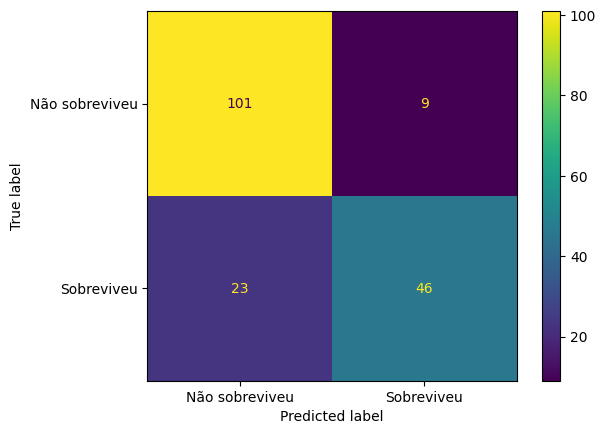

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

matriz_final = confusion_matrix(y_test, y_pred_final)

display_matriz = ConfusionMatrixDisplay(
    confusion_matrix=matriz_final,
    display_labels=["Não sobreviveu", "Sobreviveu"]
)

display_matriz.plot()

## 23. Análise dos resultados finais

O Random Forest otimizado foi avaliado no conjunto de teste reservado,
obtendo os seguintes resultados:

- Accuracy: 0.8212
- Precision: 0.8364
- Recall: 0.6667
- F1-score: 0.7419
- AUC-ROC: 0.8453

A matriz de confusão mostrou:

- 101 verdadeiros negativos;
- 9 falsos positivos;
- 23 falsos negativos;
- 46 verdadeiros positivos.

O modelo apresentou boa precisão ao prever sobreviventes, acertando
aproximadamente 83,6% dos passageiros classificados como sobreviventes.

Entretanto, o Recall de aproximadamente 66,7% mostra que o modelo deixou
de identificar parte dos passageiros que realmente sobreviveram.

A AUC-ROC de aproximadamente 0.845 indica boa capacidade de discriminação
entre sobreviventes e não sobreviventes.

### 23.1 Comparação entre validação cruzada e teste final

Os resultados do conjunto de teste foram próximos das médias encontradas
durante a validação cruzada.

Accuracy, Precision, Recall e F1-score apresentaram diferenças pequenas,
indicando que o desempenho observado durante a validação foi mantido em
dados não utilizados na seleção do modelo.

A AUC-ROC apresentou uma redução em relação à média da validação cruzada,
mas permaneceu em um nível satisfatório.

De forma geral, os resultados sugerem que o modelo apresenta capacidade
adequada de generalização para os dados analisados.

In [63]:
comparacao_final = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC-ROC"
    ],

    "Validação Cruzada": [
        0.817171,
        0.824382,
        0.671690,
        0.737537,
        0.873226
    ],

    "Teste Final": [
        accuracy_final,
        precision_final,
        recall_final,
        f1_final,
        auc_final
    ]
})

comparacao_final

,Métrica,Validação Cruzada,Teste Final
0,Accuracy,0.817171,0.821229
1,Precision,0.824382,0.836364
2,Recall,0.671690,0.666667
3,F1-score,0.737537,0.741935
4,AUC-ROC,0.873226,0.845323


## 24. Conclusão

Neste projeto, foram desenvolvidos e avaliados diferentes modelos de Machine
Learning com o objetivo de prever a sobrevivência dos passageiros do Titanic.

Inicialmente, foi realizada uma análise exploratória da base, identificando
valores ausentes e características que precisavam de tratamento. A variável
`Title` foi extraída a partir do nome dos passageiros e utilizada como
informação auxiliar para realizar uma imputação mais adequada dos valores
ausentes de `Age`.

Também foram realizados o tratamento de `Embarked`, One-Hot Encoding das
variáveis categóricas e padronização das variáveis numéricas.

Antes da comparação dos modelos, foi definido um baseline utilizando a classe
majoritária, permitindo estabelecer uma referência mínima de desempenho.

Foram avaliados cinco algoritmos de classificação:

- Regressão Logística;
- KNN;
- Árvore de Decisão;
- Random Forest;
- SVM.

A validação cruzada com múltiplas seeds mostrou que Random Forest e SVM
apresentaram os melhores resultados gerais, sendo selecionados para a etapa
de otimização de hiperparâmetros.

Para tornar a avaliação mais rigorosa e evitar data leakage, o
pré-processamento foi posteriormente incorporado a Pipelines, garantindo que
imputação, encoding e padronização fossem aprendidos apenas com os dados de
treinamento de cada fold.

Após o Hyperparameter Tuning e uma nova validação cruzada, o Random Forest
otimizado foi selecionado como modelo final por apresentar a maior AUC-ROC
média, além de boa estabilidade entre diferentes divisões dos dados.

Na avaliação final no conjunto de teste, o modelo apresentou:

- Accuracy: 82,12%
- Precision: 83,64%
- Recall: 66,67%
- F1-score: 74,19%
- AUC-ROC: 84,53%

A matriz de confusão apresentou 101 verdadeiros negativos, 46 verdadeiros
positivos, 9 falsos positivos e 23 falsos negativos.

Os resultados mostram que o modelo possui boa capacidade de classificação,
especialmente ao identificar corretamente os passageiros classificados como
sobreviventes, refletido pela Precision de aproximadamente 83,6%.

Por outro lado, o Recall de aproximadamente 66,7% indica que parte dos
passageiros que realmente sobreviveram ainda foi classificada incorretamente
como não sobrevivente.

Os resultados obtidos no conjunto de teste também permaneceram próximos aos
observados durante a validação cruzada, indicando que o modelo manteve um
desempenho consistente em dados não utilizados durante sua seleção.

Portanto, o Random Forest apresentou um desempenho satisfatório para o
problema proposto. Entretanto, não existe um único modelo universalmente
"melhor": a escolha depende da métrica considerada e dos custos associados
aos diferentes tipos de erro.

### 24.1 Possíveis melhorias futuras

Como continuidade do projeto, poderiam ser exploradas novas estratégias de
Feature Engineering, como utilizar `Title` diretamente como variável
preditora, extrair informações da cabine e criar características relacionadas
ao tamanho da família.

Também seria possível testar novos algoritmos, ampliar a busca de
hiperparâmetros e analisar diferentes thresholds de classificação para
modificar o equilíbrio entre Precision e Recall.

Essas etapas permitiriam investigar se é possível melhorar ainda mais a
capacidade de generalização do modelo.